In [1]:
import matplotlib.pyplot as plt
import numpy as np
import util
import pandas as pd
from classical_strategies import baseload
from tabulate import tabulate

In [2]:
model_1, dataset, config_1 = util.load_experiment('a31cccc7-7bab-47a3-a7dc-572aef7b6a5b', '../../data/processed/dataset_2018-21_withloads.csv', with_loads=True)
model_2, _, _ = util.load_experiment('5130b3e6-7406-47bd-83dd-1c5d0f45fce4', '../../data/processed/dataset_2018-21_withloads.csv', with_loads=True)
model_3, _, _ = util.load_experiment('194449e3-9337-4a66-a4f5-98b14c9e0a87', '../../data/processed/dataset_2018-21_withloads.csv', with_loads=True)
model_4, _, _ = util.load_experiment('335a43f3-17c7-4b91-9127-2b8aa4becf21', '../../data/processed/dataset_2018-21_withloads.csv', with_loads=True)
model_5, _, _ = util.load_experiment('b82524d6-dfe2-4187-b358-6a52cd5e7446', '../../data/processed/dataset_2018-21_withloads.csv', with_loads=True)
model_6, _, _ = util.load_experiment('4598a576-6095-4124-a9cf-6d24d2d8138c', '../../data/processed/dataset_2018-21_withloads.csv', with_loads=True)

/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = th

/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/3404069657.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coves[i,0] = util.cove(power, price, config['battery_rating'], config['battery_duration'])
/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/3404069657.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coves[i,j+1] = util.cove(released, price, config['battery_rating'], config['battery_duration'])
/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/3404069657.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you 

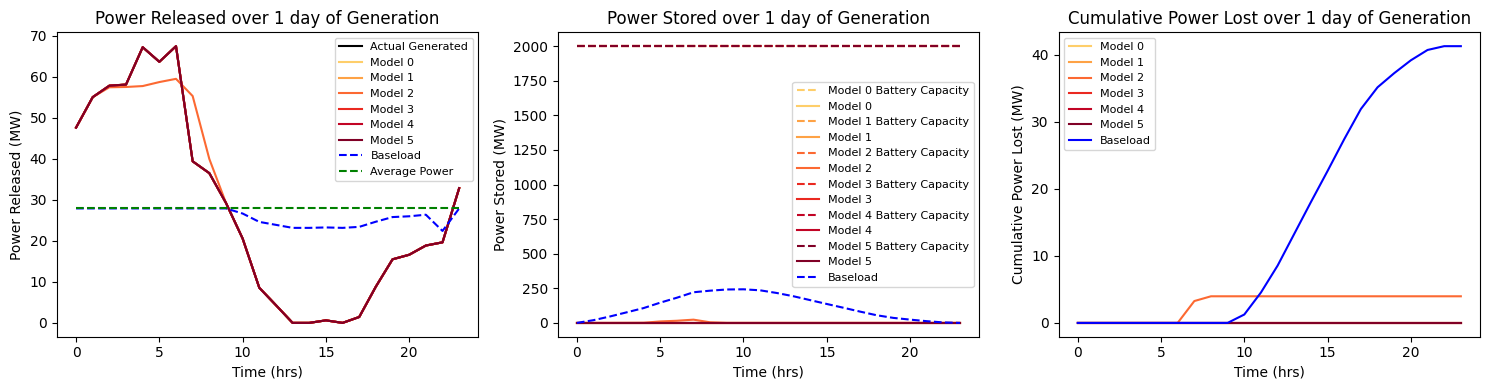

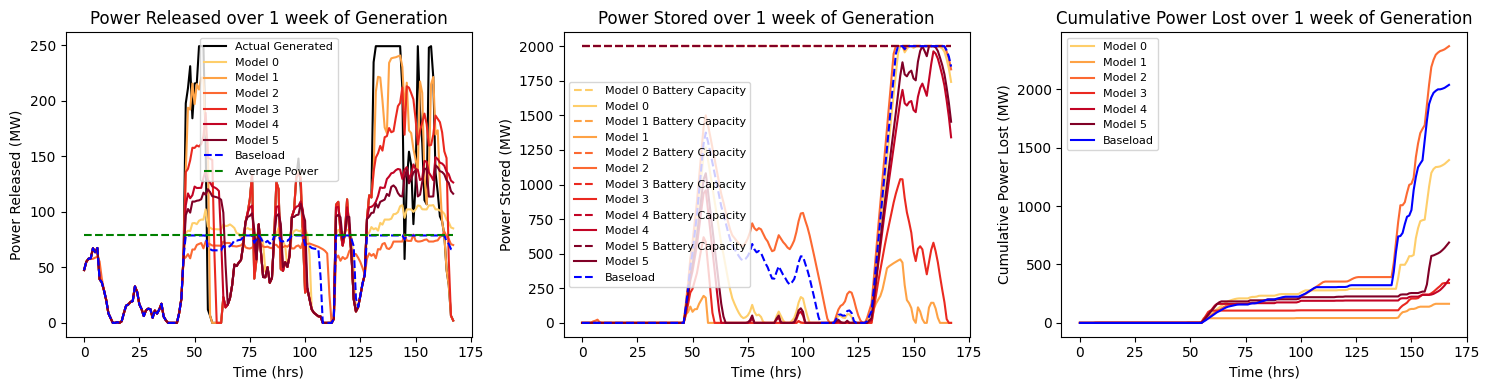

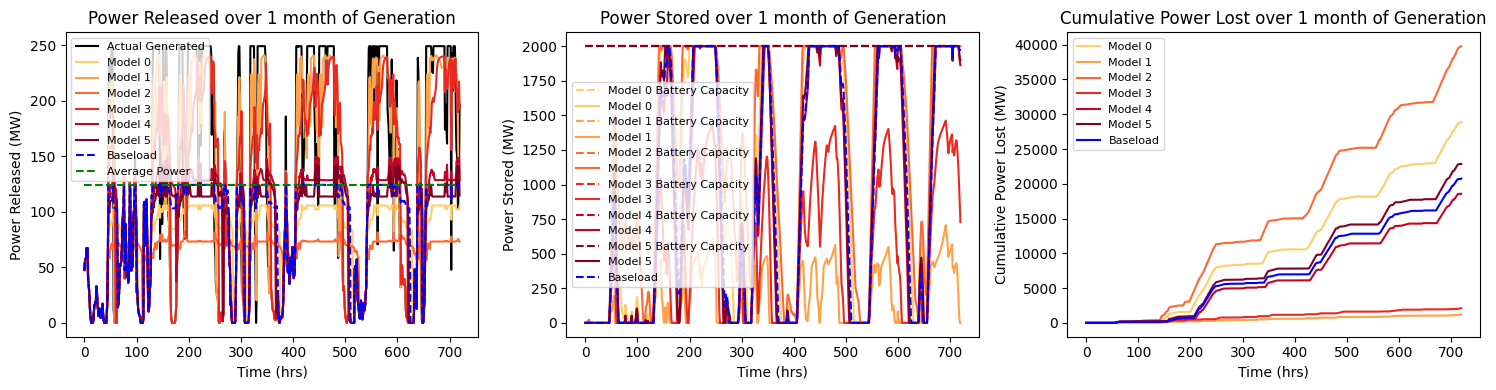

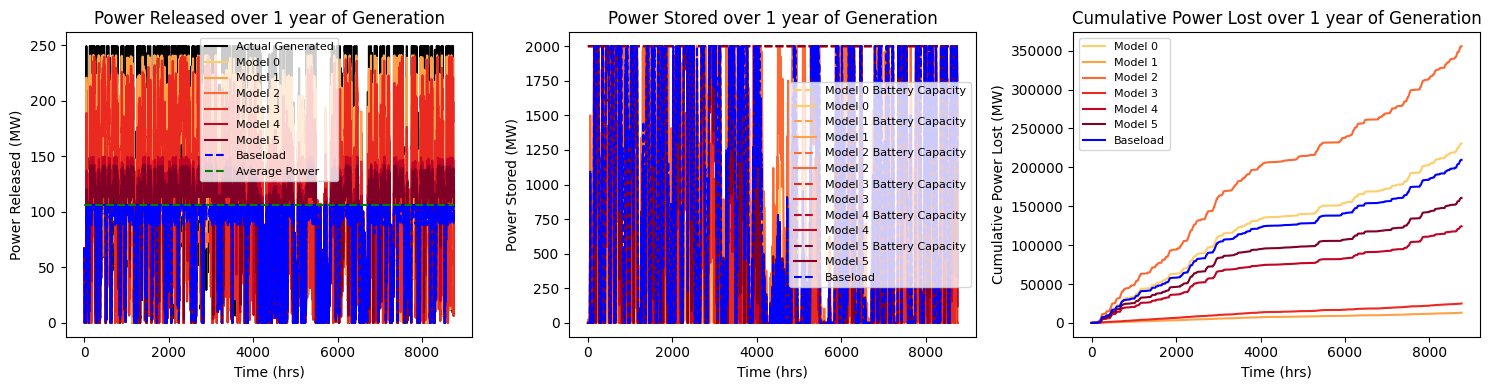

In [3]:
scales = ['1 day', '1 week', '1 month', '1 year']
upper_bounds = [24, 24*7, 24*30, 24*365]

models = [model_1, model_2, model_3, model_4, model_5, model_6]
config = config_1

S = len(scales)
M = len(models)

vfs = np.zeros((S,M+2))
coves = np.zeros((S,M+2))

for i in range(len(scales)):
    data = dataset[:upper_bounds[i], :]
    power = data[:,0].detach().cpu().numpy().squeeze()
    price = data[:,1].detach().cpu().numpy().squeeze()
    loads = data[:,2].detach().cpu().numpy().squeeze()

    vfs[i, 0] = util.value_factor(power, price)
    coves[i,0] = util.cove(power, price, config['battery_rating'], config['battery_duration']) 

    x = np.arange(0, len(power))

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    cmap = plt.get_cmap('YlOrRd', M + 2)

    avg_power = np.repeat(np.mean(power), len(x))
    ax1.plot(x, power, 'black', label='Actual Generated')

    for j in range(M):
        model = models[j]

        ax2.plot(x, np.repeat(config['battery_rating'] * config['battery_duration'], len(x)), color=cmap(j + 2), ls='--', label=f'Model {j} Battery Capacity')
        pred = model(data.unsqueeze(0)).detach().cpu().numpy().squeeze()
        released = pred[:,0]
        stored = pred[:,1]
        lost = pred[:,2]

        vfs[i, j+1] = util.value_factor(released, price)
        coves[i,j+1] = util.cove(released, price, config['battery_rating'], config['battery_duration']) 

        ax1.plot(x, released, color=cmap(j + 2), label=f'Model {j}')
        ax2.plot(x, stored, color=cmap(j + 2), label=f'Model {j}')
        ax3.plot(x, np.cumsum(lost), color=cmap(j+2), label=f'Model {j}')
    # Compare baseload "cheating" strategy
    baseload_released, baseload_stored, baseload_losses = baseload(power, config['battery_rating'], config['battery_rating'] * config['battery_duration'], util.RTE)

    vfs[i, -1] = util.value_factor(baseload_released, price)
    coves[i,-1] = util.cove(baseload_released, price, config['battery_rating'], config['battery_duration']) 
    
    ax1.plot(x, baseload_released, color='blue', ls='--', label=f'Baseload')
    ax2.plot(x, baseload_stored, color='blue', ls='--', label=f'Baseload')

    ax3.plot(x, np.cumsum(baseload_losses), color='b', label=f'Baseload')

    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Power Released (MW)')
    ax1.set_title(f'Power Released over {scales[i]} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Power Stored (MW)')
    ax2.set_title(f'Power Stored over {scales[i]} of Generation')
    ax2.legend(fontsize=8)

    ax3.set_xlabel('Time (hrs)')
    ax3.set_ylabel('Cumulative Power Lost (MW)')
    ax3.set_title(f'Cumulative Power Lost over {scales[i]} of Generation')
    ax3.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    

In [4]:
strategy_names = ["Raw", "NN1", "NN2", "NN3", "NN4", "NN5", "NN6", "Baseload"]
for i in range(S):
    print(f'Performance for {scales[i]} of power generation')
    metrics = {
        'Strategy': strategy_names,
        'VF': vfs[i,:],
        'COVE': coves[i,:],
        'Beats Baseload in VF?': vfs[i,:] > vfs[i,-1],
        'Beats Baseload in COVE?': coves[i,:] < coves[i,-1]
    }
    df = pd.DataFrame(metrics)
    print(tabulate(df, headers='keys', tablefmt='psql'))

Performance for 1 day of power generation
+----+------------+----------+---------+-------------------------+---------------------------+
|    | Strategy   |       VF |    COVE | Beats Baseload in VF?   | Beats Baseload in COVE?   |
|----+------------+----------+---------+-------------------------+---------------------------|
|  0 | Raw        | 0.954902 | 36.4235 | False                   | True                      |
|  1 | NN1        | 0.954902 | 36.4235 | False                   | True                      |
|  2 | NN2        | 0.954902 | 36.4235 | False                   | True                      |
|  3 | NN3        | 0.960174 | 36.4507 | False                   | True                      |
|  4 | NN4        | 0.954902 | 36.4235 | False                   | True                      |
|  5 | NN5        | 0.954902 | 36.4235 | False                   | True                      |
|  6 | NN6        | 0.954902 | 36.4235 | False                   | True                      |
|  7 | B

/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/2949813690.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coves[i,0] = util.cove(power, price, config['battery_rating'], config['battery_duration'])
/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/2949813690.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coves[i,j+1] = util.cove(released, price, config['battery_rating'], config['battery_duration'])
/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/2949813690.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you 

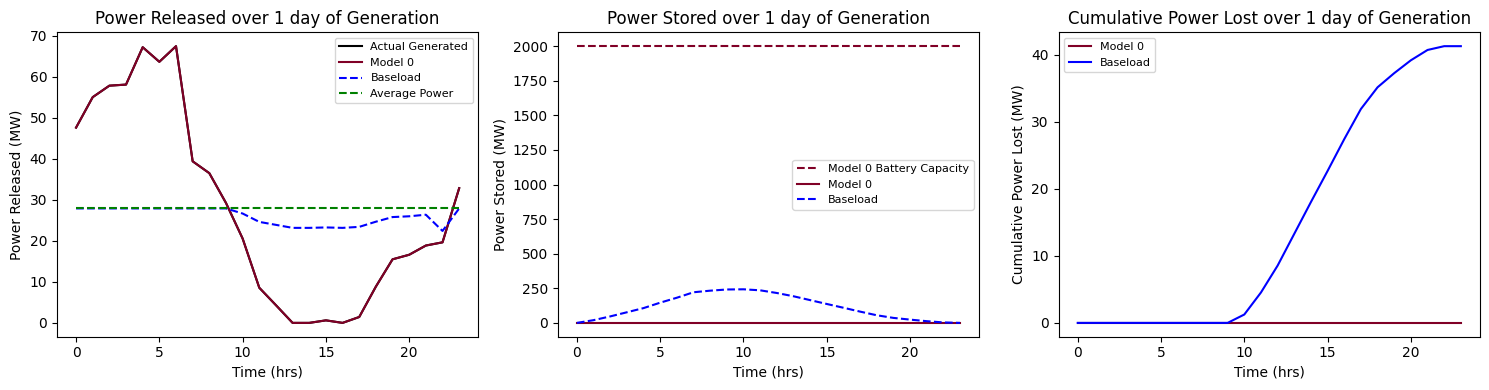

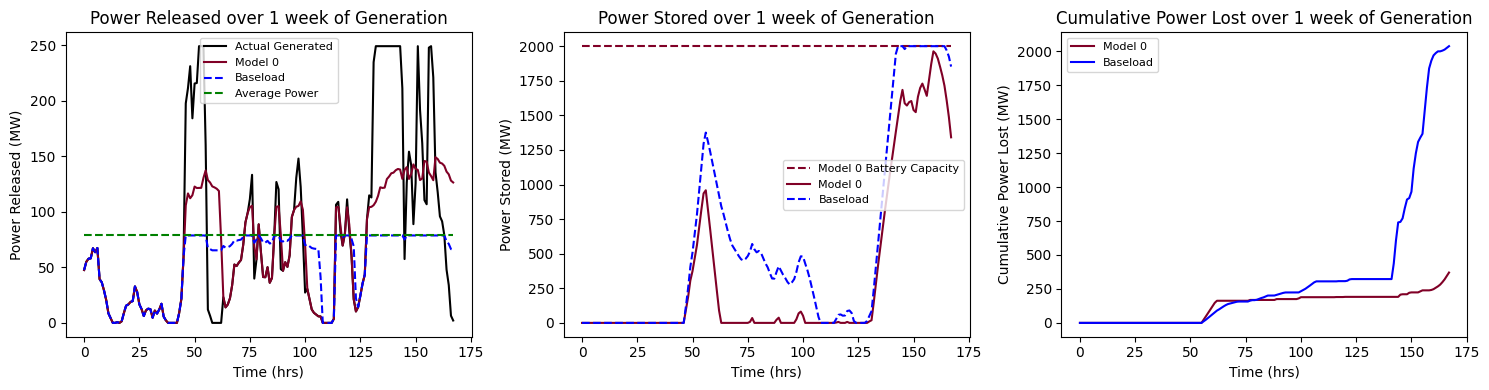

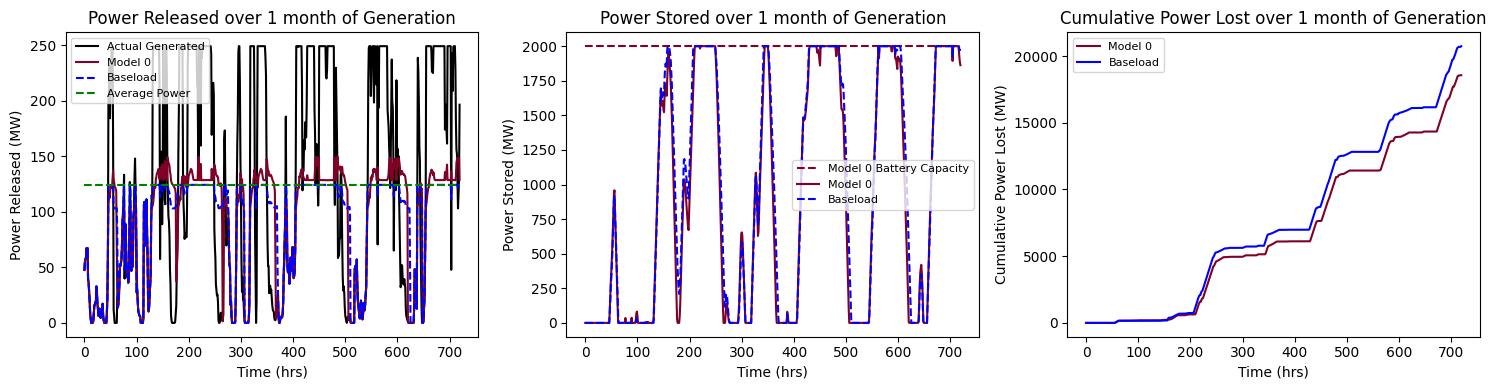

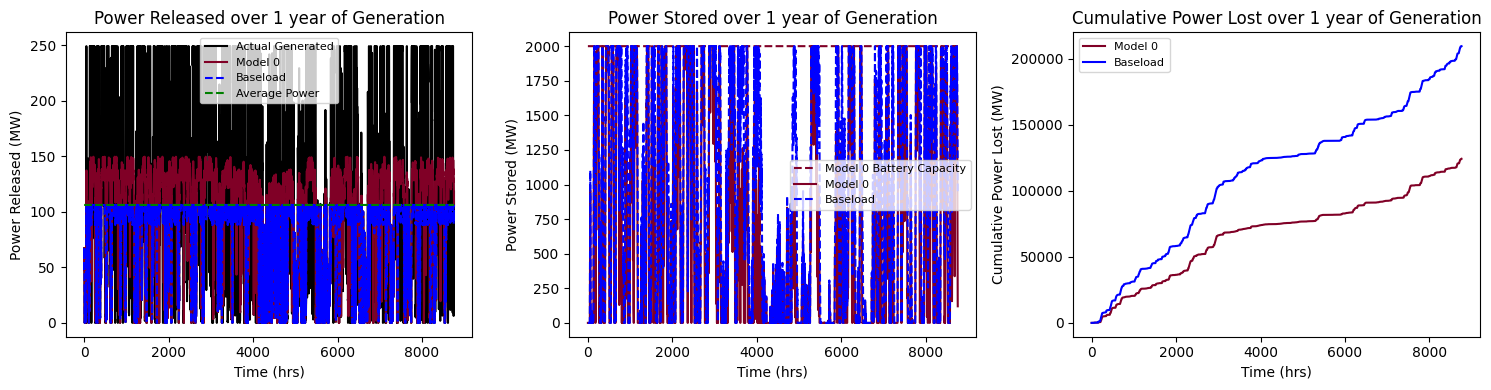

In [5]:
scales = ['1 day', '1 week', '1 month', '1 year']
upper_bounds = [24, 24*7, 24*30, 24*365]

models = [model_5]
config = config_1

S = len(scales)
M = len(models)

vfs = np.zeros((S,M+2))
coves = np.zeros((S,M+2))

for i in range(len(scales)):
    data = dataset[:upper_bounds[i], :]
    power = data[:,0].detach().cpu().numpy().squeeze()
    price = data[:,1].detach().cpu().numpy().squeeze()
    loads = data[:,2].detach().cpu().numpy().squeeze()

    vfs[i, 0] = util.value_factor(power, price)
    coves[i,0] = util.cove(power, price, config['battery_rating'], config['battery_duration']) 

    x = np.arange(0, len(power))

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    cmap = plt.get_cmap('YlOrRd', M + 2)

    avg_power = np.repeat(np.mean(power), len(x))
    ax1.plot(x, power, 'black', label='Actual Generated')

    for j in range(M):
        model = models[j]

        ax2.plot(x, np.repeat(config['battery_rating'] * config['battery_duration'], len(x)), color=cmap(j + 2), ls='--', label=f'Model {j} Battery Capacity')
        pred = model(data.unsqueeze(0)).detach().cpu().numpy().squeeze()
        released = pred[:,0]
        stored = pred[:,1]
        lost = pred[:,2]

        vfs[i, j+1] = util.value_factor(released, price)
        coves[i,j+1] = util.cove(released, price, config['battery_rating'], config['battery_duration']) 

        ax1.plot(x, released, color=cmap(j + 2), label=f'Model {j}')
        ax2.plot(x, stored, color=cmap(j + 2), label=f'Model {j}')
        ax3.plot(x, np.cumsum(lost), color=cmap(j+2), label=f'Model {j}')
    # Compare baseload "cheating" strategy
    baseload_released, baseload_stored, baseload_losses = baseload(power, config['battery_rating'], config['battery_rating'] * config['battery_duration'], util.RTE)

    vfs[i, -1] = util.value_factor(baseload_released, price)
    coves[i,-1] = util.cove(baseload_released, price, config['battery_rating'], config['battery_duration']) 
    
    ax1.plot(x, baseload_released, color='blue', ls='--', label=f'Baseload')
    ax2.plot(x, baseload_stored, color='blue', ls='--', label=f'Baseload')

    ax3.plot(x, np.cumsum(baseload_losses), color='b', label=f'Baseload')

    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Power Released (MW)')
    ax1.set_title(f'Power Released over {scales[i]} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Power Stored (MW)')
    ax2.set_title(f'Power Stored over {scales[i]} of Generation')
    ax2.legend(fontsize=8)

    ax3.set_xlabel('Time (hrs)')
    ax3.set_ylabel('Cumulative Power Lost (MW)')
    ax3.set_title(f'Cumulative Power Lost over {scales[i]} of Generation')
    ax3.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    

/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_3732/3721041649.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coves[i,j] = util.cove(baseload_released, price, rating, duration)


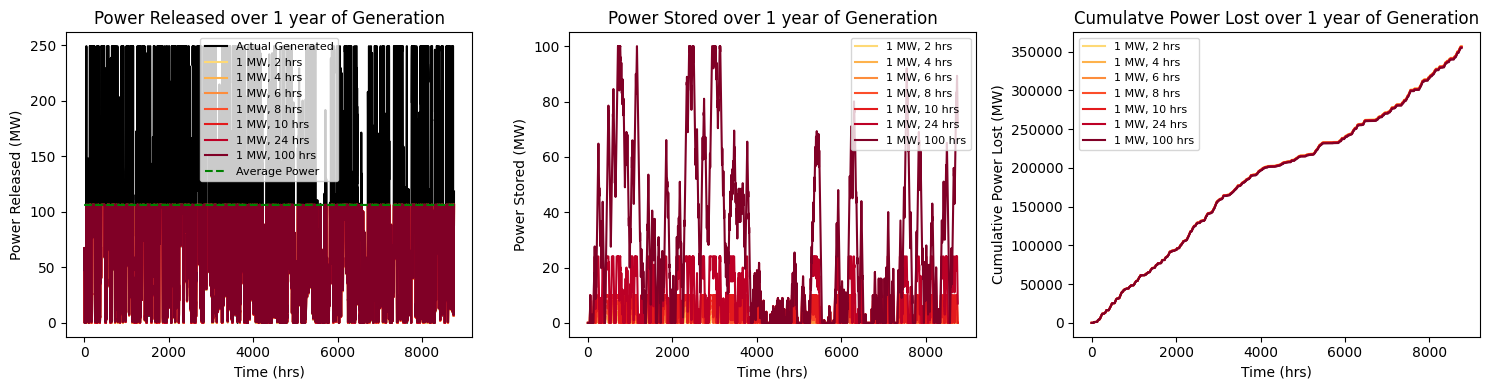

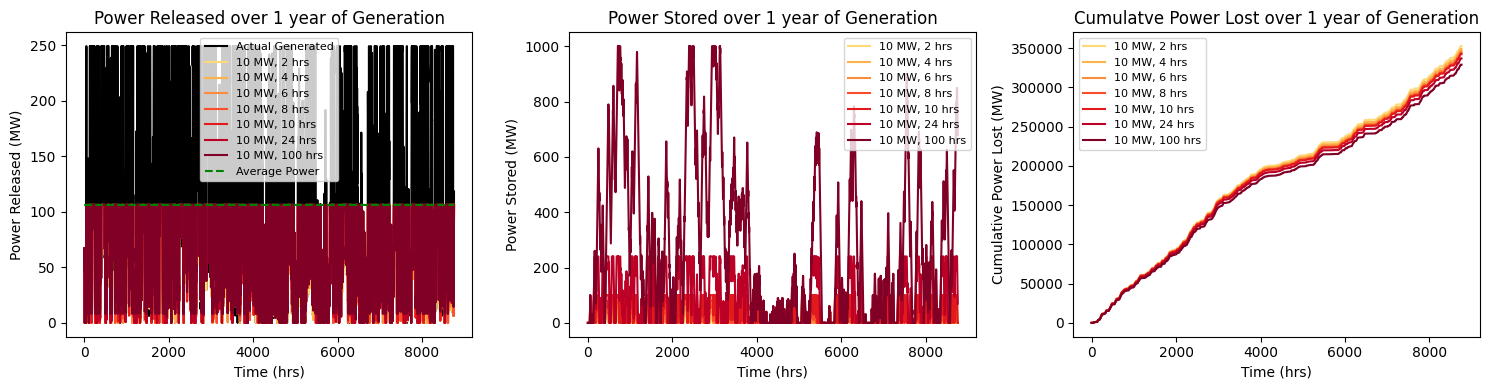

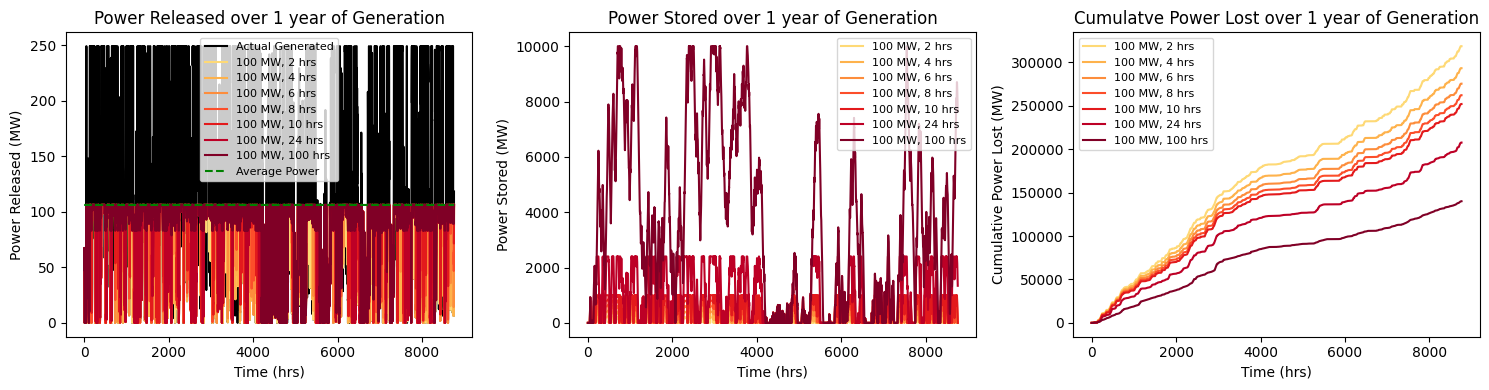

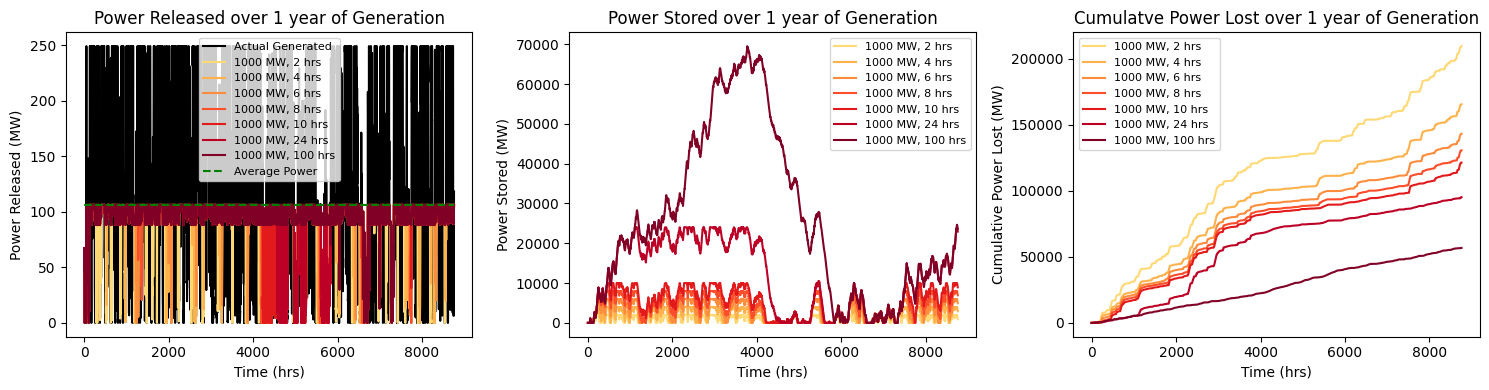

In [8]:
scale = '1 year'
upper_bound = 24 * 365

data = dataset[:upper_bound, :]
power = data[:,0].detach().cpu().numpy().squeeze()
price = data[:,1].detach().cpu().numpy().squeeze()
x = np.arange(0, len(power))
avg_power = np.repeat(np.mean(power), len(x))

ratings = [1, 10, 100, 1000]
durations = [2, 4, 6, 8, 10, 24, 100]

R = len(ratings)
D = len(durations)

vfs = np.zeros((R,D))
coves = np.zeros((R,D))

for i in range(R):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    cmap = plt.get_cmap('YlOrRd', D + 2)

    ax1.plot(x, power, 'black', label='Actual Generated')

    for j in range(D):
        rating = ratings[i]
        duration = durations[j]
        capacity = rating * duration

        baseload_released, baseload_stored, baseload_losses = baseload(power, rating, capacity, util.RTE)

        vfs[i,j] = util.value_factor(baseload_released, price)
        coves[i,j] = util.cove(baseload_released, price, rating, duration)
        
        ax1.plot(x, baseload_released, color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')
        ax2.plot(x, baseload_stored, color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')
        ax3.plot(x, np.cumsum(baseload_losses), color=cmap(j + 2), label=f'{rating} MW, {duration} hrs')

    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Power Released (MW)')
    ax1.set_title(f'Power Released over {scale} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Power Stored (MW)')
    ax2.set_title(f'Power Stored over {scale} of Generation')
    ax2.legend(fontsize=8)

    ax3.set_xlabel('Time (hrs)')
    ax3.set_ylabel('Cumulative Power Lost (MW)')
    ax3.set_title(f'Cumulatve Power Lost over {scale} of Generation')
    ax3.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    

In [7]:
strategy_names = ["Raw", ""]
for i in range(R):
    print(f'Performance using Rating {ratings[i]} MW battery')
    metrics = {
        'Duration': durations,
        'VF': vfs[i,:],
        'COVE': coves[i,:]
    }
    df = pd.DataFrame(metrics)
    print(tabulate(df, headers='keys', tablefmt='psql'))

min_cove = np.min(coves)
max_vf = np.max(vfs)
print(f'Minimum COVE: {min_cove} (w/ {ratings[np.where(coves == min_cove)[0][0]]} MW, {durations[np.where(coves == min_cove)[1][0]]} hrs)')
print(f'Maximum VF: {max_vf} (w/ {ratings[np.where(vfs == max_vf)[0][0]]} MW, {durations[np.where(vfs == max_vf)[1][0]]} hrs)')

Performance using Rating 1 MW battery
+----+------------+----------+-----------+
|    |   Duration |       VF |      COVE |
|----+------------+----------+-----------|
|  0 |          2 | 0.755263 | 0.0907143 |
|  1 |          4 | 0.755625 | 0.160316  |
|  2 |          6 | 0.756056 | 0.230212  |
|  3 |          8 | 0.756543 | 0.299879  |
|  4 |         10 | 0.756672 | 0.369402  |
|  5 |         24 | 0.75719  | 0.852527  |
|  6 |        100 | 0.757759 | 3.43651   |
+----+------------+----------+-----------+
Performance using Rating 10 MW battery
+----+------------+----------+----------+
|    |   Duration |       VF |     COVE |
|----+------------+----------+----------|
|  0 |          2 | 0.757292 | 0.077988 |
|  1 |          4 | 0.760941 | 0.138003 |
|  2 |          6 | 0.76529  | 0.198278 |
|  3 |          8 | 0.769749 | 0.256528 |
|  4 |         10 | 0.770926 | 0.315609 |
|  5 |         24 | 0.775812 | 0.722121 |
|  6 |        100 | 0.780974 | 2.8686   |
+----+------------+----------+